<a href="https://colab.research.google.com/github/olaidczak/speech-commands-transformers/blob/main/dl_project_2_v1_mik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# v3 (dont use)

In [ ]:
!wget -q http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
!mkdir -p /content/data/SpeechCommands/speech_commands_v0.01
!tar -xf speech_commands_v0.01.tar.gz -C /content/data/SpeechCommands/speech_commands_v0.01
!rm speech_commands_v0.01.tar.gz

In [ ]:
import os
import random
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from tqdm.auto import tqdm
from transformers import ASTFeatureExtractor, ASTForAudioClassification

In [ ]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["_silence_", "_unknown_"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000

In [ ]:
class SC12(Dataset):
    def __init__(self, root, subset, train_fraction=1.0, max_samples=None):
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset

        # Bucket every sample into targets or unknowns
        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        # If this is the training set, take only `train_fraction` of each class
        if subset == "training" and train_fraction < 1.0:
            rng = random.Random(42)
            for w in TARGET_WORDS:
                idxs = targets_by_word[w]
                rng.shuffle(idxs)
                keep = max(1, int(len(idxs) * train_fraction))
                targets_by_word[w] = idxs[:keep]
            rng.shuffle(unknown_indices)
            unknown_keep = max(1, int(len(unknown_indices) * train_fraction))
            unknown_indices = unknown_indices[:unknown_keep]

        # Flatten target indices
        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match silence and unknown counts to the average target count
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]
        self.n_silence = avg_per_target

        # --- Cap total samples to max_samples while preserving class distribution ---
        if max_samples is not None:
            # There are (len(TARGET_WORDS) + 2) classes: one per target word + unknown + silence
            n_classes = len(TARGET_WORDS) + 2
            per_class = max(1, max_samples // n_classes)

            # Cap each target word proportionally
            rng = random.Random(7)
            new_target_indices = []
            for w in TARGET_WORDS:
                # Gather indices belonging to this word
                word_indices = [
                    i for i in self.target_indices
                    if self.base.get_metadata(i)[2] == w
                ]
                rng.shuffle(word_indices)
                new_target_indices.extend(word_indices[:per_class])
            self.target_indices = new_target_indices

            # Cap unknown and silence to the same per_class budget
            unknown_list = list(self.unknown_indices)
            rng.shuffle(unknown_list)
            self.unknown_indices = unknown_list[:per_class]
            self.n_silence = per_class

        # Load background noise clips
        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        # For val/test, use a fixed silence plan so evaluation is deterministic
        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            pad_amount = CLIP_LEN - wav.size(0)
            return torch.nn.functional.pad(wav, (0, pad_amount))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        n_unknowns = len(self.unknown_indices)

        # Target word
        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX[label]

        # Unknown word
        idx -= n_targets
        if idx < n_unknowns:
            wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX["_unknown_"]

        # Silence (background noise crop)
        idx -= n_unknowns
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX["_silence_"]

In [ ]:
def make_ast_collate(feature_extractor):
    def collate(batch):
        wavs, labels = zip(*batch)
        wavs_np = [w.numpy() for w in wavs]
        inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs
    return collate


def make_kwt_collate():
    mfcc = torchaudio.transforms.MFCC(
        sample_rate=SAMPLE_RATE,
        n_mfcc=40,
        melkwargs={"n_fft": 480, "hop_length": 160, "n_mels": 40},
    )

    def collate(batch):
        wavs, labels = zip(*batch)
        wavs = torch.stack(wavs)
        feats = mfcc(wavs)                     # (B, 40, 101)
        feats = feats.transpose(1, 2)          # (B, 101, 40)
        return feats, torch.tensor(labels)
    return collate

In [ ]:
def train_one_epoch_ast(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(loader, desc="train", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.logits.argmax(-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_ast(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(loader, desc="eval", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]
        outputs = model(**batch)

        total_loss += outputs.loss.item() * labels.size(0)
        correct += (outputs.logits.argmax(-1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


In [ ]:
feature_extractor.do_normalize = False  # we set normalization to False in order to calculate the mean + std of the dataset
mean = []
std = []

# we use the transformation w/o augmentation on the training dataset to calculate the mean + std
dataset["train"].set_transform(preprocess_audio, output_all_columns=False)
for i, (audio_input, labels) in enumerate(dataset["train"]):
    cur_mean = torch.mean(dataset["train"][i][audio_input])
    cur_std = torch.std(dataset["train"][i][audio_input])
    mean.append(cur_mean)
    std.append(cur_std)
feature_extractor.mean = np.mean(mean)
feature_extractor.std = np.mean(std)
feature_extractor.do_normalize = True


def compute_dataset_stats(dataset, feature_extractor):
    all_means = []
    all_stds = []
    feature_extractor.do_normalize = False
    for x, _ in dataset:
        inputs = feature_extractor(
            x,
            sampling_rate=16000,
            return_tensors="pt"
        )
        feats = inputs["input_values"]  # shape: (1, time, freq)

        all_means.append(feats.mean().item())
        all_stds.append(feats.std().item())

    mean = sum(all_means) / len(all_means)
    std = sum(all_stds) / len(all_stds)
    return mean, std

NameError: name 'feature_extractor' is not defined

In [ ]:
def train_ast(train_ds, val_ds, test_ds, device, epochs=3, batch_size=8, lr=1e-5):
    model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
    feature_extractor = ASTFeatureExtractor.from_pretrained(model_id)
    mean, std = compute_dataset_stats(train_ds, feature_extractor)
    feature_extractor.mean = mean
    feature_extractor.std = std
    feature_extractor.do_normalize = True

    model = ASTForAudioClassification.from_pretrained(
        model_id,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,
    )
    model.gradient_checkpointing_enable()   # save GPU memory
    model.to(device)

    collate = make_ast_collate(feature_extractor)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              collate_fn=collate, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            collate_fn=collate, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             collate_fn=collate, num_workers=2)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val_acc = 0.0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch_ast(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate_ast(model, val_loader, device)
        print(f"[AST] epoch {epoch} | train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # torch.save(model.state_dict(), "ast_best.pt")

    # model.load_state_dict(torch.load("ast_best.pt", map_location=device))
    # test_loss, test_acc = evaluate_ast(model, test_loader, device)
    # print(f"[AST] TEST loss {test_loss:.4f} acc {test_acc:.4f}")
    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
root="/content/data"
train_ds = SC12(root, "training", train_fraction=0.1)
val_ds = SC12(root, "validation", max_samples=1000)
test_ds = SC12(root, "testing",  max_samples=800)
print(f"train: {len(train_ds)}   val: {len(val_ds)}   test: {len(test_ds)}")


device: cuda
train: 2220   val: 996   test: 792


In [ ]:
train_ast(train_ds, val_ds, test_ds, device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

NameError: name 'compute_dataset_stats' is not defined

# v4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# Definiujemy folder na wyniki (możesz go zmienić)
save_path = "/content/drive/MyDrive/transformer_sound/"

# Jeśli folder nie istnieje, stwórz go
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [1]:
!wget -q http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
!mkdir -p /content/data/SpeechCommands/speech_commands_v0.01
!tar -xf speech_commands_v0.01.tar.gz -C /content/data/SpeechCommands/speech_commands_v0.01
!rm speech_commands_v0.01.tar.gz

In [2]:
import torch
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    TrainingArguments,
    Trainer,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
import numpy as np
import os
import random
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from tqdm.auto import tqdm
# import evaluate

In [45]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["unknown", "silence"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000

class SC12(Dataset):
    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        """
        Args:
            root:             Dataset root directory.
            subset:           One of "training", "validation", "testing".
            train_fraction:   Fraction of training data to keep (0.0–1.0).
            valid_fraction:   Fraction of validation data to keep (0.0–1.0).
            test_fraction:    Fraction of test data to keep (0.0–1.0).
        """
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset

        # Pick the right fraction for this split
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        # Bucket every sample into targets or unknowns
        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        # Apply fraction per class (all splits)
        rng = random.Random(42)
        for w in TARGET_WORDS:
            idxs = targets_by_word[w]
            rng.shuffle(idxs)
            keep = max(1, int(len(idxs) * fraction))
            targets_by_word[w] = idxs[:keep]
        rng.shuffle(unknown_indices)
        unknown_indices = unknown_indices[:max(1, int(len(unknown_indices) * fraction))]

        # Flatten target indices
        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match silence and unknown counts to the average target count
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]
        self.n_silence = avg_per_target

        # Load background noise clips
        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        # For val/test, use a fixed silence plan so evaluation is deterministic
        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            pad_amount = CLIP_LEN - wav.size(0)
            return torch.nn.functional.pad(wav, (0, pad_amount))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        n_unknowns = len(self.unknown_indices)

        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX[label]

        idx -= n_targets
        if idx < n_unknowns:
            wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX["unknown"]

        idx -= n_unknowns
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX["silence"]


def make_ast_collate(feature_extractor):
    def collate(batch):
        wavs, labels = zip(*batch)
        wavs_np = [w.numpy() for w in wavs]
        inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs
    return collate

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
root="/content/data"

# original split: train ~22 000, valid 3091, test: 3079
train_ds = SC12(root, "training", train_fraction=0.1)
val_ds = SC12(root, "validation", valid_fraction=0.66)
test_ds = SC12(root, "testing",  test_fraction=0.66)

print(f"train {len(train_ds)}")
print(f"valid {len(val_ds)}")
print(f"test {len(test_ds)}")


device: cuda
train 2220
valid 2034
test 2024


In [4]:
def compute_dataset_stats(dataset, feature_extractor, n_samples=2000):
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    feature_extractor.do_normalize = False

    all_means, all_stds = [], []
    for i in indices:
        x, _ = dataset[i]
        feats = feature_extractor(x.numpy(), sampling_rate=16000, return_tensors="pt")["input_values"]
        all_means.append(feats.mean().item())
        all_stds.append(feats.std().item())

    return sum(all_means) / len(all_means), sum(all_stds) / len(all_stds)

In [11]:
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
mean, std = compute_dataset_stats(train_ds, feature_extractor)
# !! Compute these from YOUR dataset, or fall back to AudioSet defaults
# from transformers import ASTFeatureExtractor
feature_extractor.mean = mean
feature_extractor.std  = std
feature_extractor.do_normalize = True
collate = make_ast_collate(feature_extractor)

In [12]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
# del model, trainer

In [13]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
# ── 1. Labels ────────────────────────────────────────────────────────────────
label2id = {
    "yes": 0, "no": 1, "up": 2, "down": 3, "left": 4,
    "right": 5, "on": 6, "off": 7, "stop": 8, "go": 9,
    "unknown": 10, "silence": 11,
}
id2label = {v: k for k, v in label2id.items()}
num_labels = 12

# ── 2. Feature extractor ──────────────────────────────────────────────────────
# MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
# feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
# mean, std = compute_dataset_stats(train_ds, feature_extractor)
# # !! Compute these from YOUR dataset, or fall back to AudioSet defaults
# # from transformers import ASTFeatureExtractor
# feature_extractor.mean = mean
# feature_extractor.std  = std
# feature_extractor.do_normalize = True
# collate = make_ast_collate(feature_extractor)

# TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
# LABELS = TARGET_WORDS + ["silence", "unknown"]
# LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
# ── 3. Model ──────────────────────────────────────────────────────────────────
model = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=12,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # replaces the 527-class AudioSet head
)

# ── 4. Preprocessing ──────────────────────────────────────────────────────────
def preprocess(batch):
    wavs = [np.array(a["array"], dtype=np.float32) for a in batch["audio"]]
    inputs = feature_extractor(
        wavs,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    )
    inputs["labels"] = torch.tensor(
        [label2id[l] for l in batch["label"]], dtype=torch.long
    )
    return inputs

# ── 5. Metrics ────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# ── 6. Training arguments ─────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./ast-speech-commands",

    # Batch & accumulation
    # per_device_train_batch_size=32,
    # per_device_eval_batch_size=32,
    # gradient_accumulation_steps=4,        # effective batch size = 128


    per_device_train_batch_size=16,   # down from 32
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,    # keep effective batch = 128

    gradient_checkpointing=True,      # trades compute for memory
    # LR & scheduler
    learning_rate=2.5e-4,
    lr_scheduler_type="cosine",         # we handle decay manually via callback
    warmup_ratio=0.05,                    # ~1 epoch warmup for 20 epochs

    # Duration
    num_train_epochs=3,

    # Precision — critical for T4 memory
    fp16=True,

    # Regularization
    weight_decay=0.01,

    # Eval & saving
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,

    # Logging
    logging_steps=10,              # log every 10 steps
    logging_strategy="steps",      # make sure it logs during training
    save_strategy="epoch",
    report_to="none",                     # swap to "tensorboard" if you want
)

# ── 7. Step-decay scheduler callback (paper recipe: ×0.85 per epoch after ep5)
# from transformers import TrainerCallback

# class StepDecayCallback(TrainerCallback):
#     def __init__(self, decay_factor=0.85, start_epoch=5):
#         self.decay = decay_factor
#         self.start = start_epoch

#     def on_epoch_begin(self, args, state, control, **kwargs):
#         epoch = int(state.epoch or 0)
#         if epoch >= self.start:
#             for pg in kwargs["optimizer"].param_groups:
#                 pg["lr"] *= self.decay
#             print(f"Epoch {epoch}: LR decayed to {kwargs['optimizer'].param_groups[0]['lr']:.2e}")

# ── 8. Trainer ────────────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,          # your HF dataset split
    eval_dataset=val_ds,
    data_collator=collate,
    compute_metrics=compute_metrics
)

# trainer.train()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([12, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([12])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.598349,1.292384,0.586345
2,0.718742,0.578824,0.810241
3,0.220737,0.461468,0.859438


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=54, training_loss=1.0262371091930955, metrics={'train_runtime': 734.1182, 'train_samples_per_second': 9.072, 'train_steps_per_second': 0.074, 'total_flos': 4.5147399112359936e+17, 'train_loss': 1.0262371091930955, 'epoch': 3.0})

In [ ]:
trainer.state.log_history  # list of dicts with loss, eval_loss, eval_accuracy, epoch

[{'loss': 2.5983488082885744,
  'grad_norm': 7.243365287780762,
  'learning_rate': 0.00024155902867554447,
  'epoch': 0.5755395683453237,
  'step': 10},
 {'eval_loss': 1.292384147644043,
  'eval_accuracy': 0.5863453815261044,
  'eval_runtime': 24.9262,
  'eval_samples_per_second': 39.958,
  'eval_steps_per_second': 2.527,
  'epoch': 1.0,
  'step': 18},
 {'loss': 1.5400720596313477,
  'grad_norm': 6.026463508605957,
  'learning_rate': 0.00019404562162006323,
  'epoch': 1.1151079136690647,
  'step': 20},
 {'loss': 0.7187420845031738,
  'grad_norm': 4.249453067779541,
  'learning_rate': 0.00012115061768047874,
  'epoch': 1.6906474820143886,
  'step': 30},
 {'eval_loss': 0.5788235068321228,
  'eval_accuracy': 0.8102409638554217,
  'eval_runtime': 25.2721,
  'eval_samples_per_second': 39.411,
  'eval_steps_per_second': 2.493,
  'epoch': 2.0,
  'step': 36},
 {'loss': 0.38719370365142824,
  'grad_norm': 3.0992627143859863,
  'learning_rate': 4.967067045259296e-05,
  'epoch': 2.230215827338129

In [15]:
# KWT AND RESNET

In [14]:
# ─── KWT (Keyword Transformer) ───────────────────────────────────────────────
import math

class KWT(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, n_mfcc=40, time_steps=101,
                 dim=64, depth=12, heads=1, mlp_dim=256, dropout=0.0):
        super().__init__()
        self.patch_embed = nn.Linear(n_mfcc, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, time_steps + 1, dim))
        enc_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads,
                    dim_feedforward=mlp_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):                          # x: (B, T, n_mfcc)
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.transformer(x)
        return self.head(self.norm(x[:, 0]))


# ─── ResNet for keyword spotting (Tang & Lin 2018) ───────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels, kernel=(3,3), dilation=(1,1)):
        super().__init__()
        pad = (dilation[0]*(kernel[0]-1)//2, dilation[1]*(kernel[1]-1)//2)
        self.conv1 = nn.Conv2d(channels, channels, kernel, padding=pad, dilation=dilation, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel, padding=pad, dilation=dilation, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        return nn.functional.relu(self.bn2(self.conv2(nn.functional.relu(self.bn1(self.conv1(x))))) + x)

class ResNetKWS(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, n_mels=40, n_frames=101,
                 n_maps=45, kernel=(3,3), dilation=(1,1), n_layers=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, n_maps, kernel,
                      padding=(dilation[0]*(kernel[0]-1)//2, dilation[1]*(kernel[1]-1)//2),
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(n_maps), nn.ReLU(),
            *[ResBlock(n_maps, kernel, dilation) for _ in range(n_layers)],
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(n_maps, num_classes)

    def forward(self, x):                          # x: (B, 1, n_mels, T)
        return self.head(self.features(x).flatten(1))


def make_mel_collate(n_mels=40):
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_fft=480, hop_length=160, n_mels=n_mels)
    def collate(batch):
        wavs, labels = zip(*batch)
        specs = torch.stack([mel(w).add_(1e-6).log_() for w in wavs])  # (B, n_mels, T)
        return specs.unsqueeze(1), torch.tensor(labels)                 # (B,1,n_mels,T)
    return collate

def make_kwt_collate(n_mfcc=40):
    mfcc = torchaudio.transforms.MFCC(
        sample_rate=SAMPLE_RATE, n_mfcc=n_mfcc,
        melkwargs={"n_fft": 480, "hop_length": 160, "n_mels": n_mfcc})
    def collate(batch):
        wavs, labels = zip(*batch)
        feats = mfcc(torch.stack(wavs)).transpose(1, 2)   # (B, T, n_mfcc)
        return feats, torch.tensor(labels)
    return collate

In [16]:
def train_loop(model, train_loader, val_loader, tag, device,
               epochs=10, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)

    history = []  # <--- INICJALIZACJA LISTY

    for epoch in range(1, epochs + 1):
        model.train()
        tloss = tcorr = ttotal = 0
        for xb, yb in tqdm(train_loader, desc="train", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tloss += loss.item() * yb.size(0); tcorr += (logits.argmax(1)==yb).sum().item(); ttotal += yb.size(0)
        scheduler.step()

        model.eval(); vloss = vcorr = vtotal = 0
        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc="val", leave=False):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                vloss += criterion(logits, yb).item()*yb.size(0); vcorr += (logits.argmax(1)==yb).sum().item(); vtotal += yb.size(0)

        # Obliczamy średnie wartości
        train_loss, train_acc = tloss/ttotal, tcorr/ttotal
        val_loss, val_acc = vloss/vtotal, vcorr/vtotal

        print(f"[{tag}] epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

        # DODAJEMY DO HISTORII
        history.append({
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })

    return model, history # <--- ZWRACAMY OBA OBIEKTY

In [35]:
kwt = KWT(dim=64, depth=12, heads=1, mlp_dim=256)
kwt_loader_tr = DataLoader(train_ds, batch_size=128, shuffle=True,  collate_fn=make_kwt_collate(), num_workers=0)
kwt_loader_vl = DataLoader(val_ds,   batch_size=128, shuffle=False, collate_fn=make_kwt_collate(), num_workers=0)
train_loop(kwt, kwt_loader_tr, kwt_loader_vl, "KWT", device, epochs=30, lr=1e-3)

/tmp/ipykernel_808/3129845299.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)


train:   0%|          | 0/18 [00:00<?, ?it/s]

val:   0%|          | 0/16 [00:00<?, ?it/s]

[KWT] epoch 01 | train loss 2.4464 acc 0.1315 | val loss 2.3064 acc 0.1554


train:   0%|          | 0/18 [00:00<?, ?it/s]

...

train:   0%|          | 0/18 [00:00<?, ?it/s]

val:   0%|          | 0/16 [00:00<?, ?it/s]

[KWT] epoch 14 | train loss 1.1541 acc 0.6072 | val loss 1.2625 acc 0.5570


train:   0%|          | 0/18 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [20]:
resnet = ResNetKWS(n_maps=45, kernel=(3,3), dilation=(1,1), n_layers=6)
res_loader_tr = DataLoader(train_ds, batch_size=128, shuffle=True,  collate_fn=make_mel_collate(), num_workers=0)
res_loader_vl = DataLoader(val_ds,   batch_size=128, shuffle=False, collate_fn=make_mel_collate(), num_workers=0)
#train_loop(resnet, res_loader_tr, res_loader_vl, "ResNet", device, epochs=30, lr=1e-3)
resnet, history = train_loop(resnet, res_loader_tr, res_loader_vl, "ResNet", device,
                             epochs=30, lr=params["lr"])

# Zapisujemy do pliku
log_results_to_csv("hyperparameter_search.csv", "ResNetKWS", params, history)

train:   0%|          | 0/18 [00:00<?, ?it/s]

val:   0%|          | 0/16 [00:00<?, ?it/s]

[ResNet] epoch 01 | train loss 2.3664 acc 0.1734 | val loss 2.2657 acc 0.2266


train:   0%|          | 0/18 [00:00<?, ?it/s]

val:   0%|          | 0/16 [00:00<?, ?it/s]

...

[ResNet] epoch 29 | train loss 0.4677 acc 0.9216 | val loss 0.6324 acc 0.8500


train:   0%|          | 0/18 [00:00<?, ?it/s]

val:   0%|          | 0/16 [00:00<?, ?it/s]

[ResNet] epoch 30 | train loss 0.4650 acc 0.9203 | val loss 0.6330 acc 0.8530


ResNetKWS(
  (features): Sequential(
    (0): Conv2d(1, 45, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ResBlock(
      (conv1): Conv2d(45, 45, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(45, 45, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (4): ResBlock(
      (conv1): Conv2d(45, 45, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(45, 45, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(45, eps=1e-05, momentum=0.1, affine=True, track_runn

In [ ]:

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
config = {
    "learning_rate": training_args.learning_rate,
    "weight_decay": training_args.weight_decay,
    "model_name": "ast",
    "log_history": trainer.state.log_history,
}

with open(f"drive/MyDrive/results/history_{timestamp}.json", "w") as f:
    json.dump(config, f, indent=2)


FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/results/history_20260424120920.json'

Test Accuracy: 0.8472

              precision    recall  f1-score   support

         yes       0.92      0.89      0.91        66
          no       0.83      0.82      0.82        66
          up       0.83      0.95      0.89        66
        down       0.86      0.77      0.82        66
        left       0.81      0.86      0.84        66
       right       0.85      0.83      0.84        66
          on       0.89      0.83      0.86        66
         off       0.92      0.86      0.89        66
        stop       0.95      0.95      0.95        66
          go       0.83      0.82      0.82        66
     silence       1.00      1.00      1.00        66
     unknown       0.51      0.56      0.54        66

    accuracy                           0.85       792
   macro avg       0.85      0.85      0.85       792
weighted avg       0.85      0.85      0.85       792



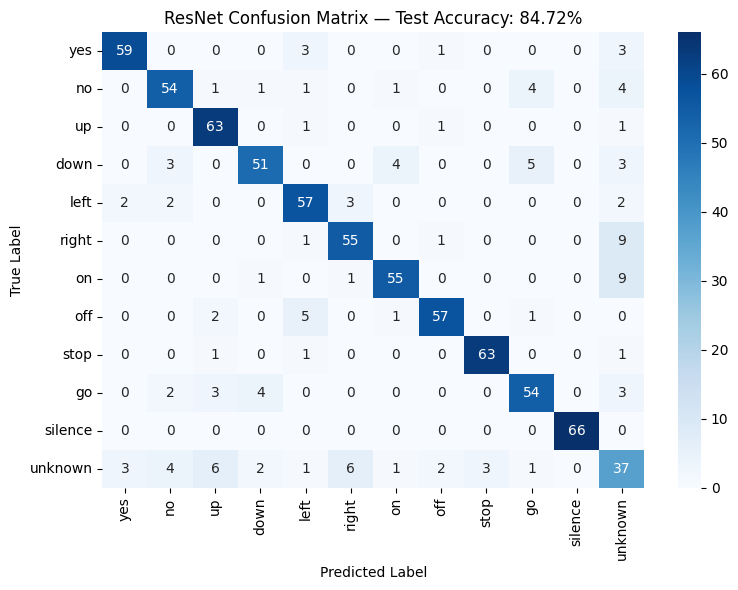

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

label_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "silence", "unknown"]

def evaluate_model(model, dataset, collate_fn, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(labels, preds, label_names, title="KWT"):
    accuracy = accuracy_score(labels, preds)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    print(classification_report(labels, preds, target_names=label_names))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"{title} Confusion Matrix — Test Accuracy: {accuracy:.2%}")
    plt.tight_layout()
    plt.show()

# KWT
#test_ds = SC12(root, "testing", max_samples=800)
#labels, preds = evaluate_model(kwt, test_ds, make_kwt_collate(), device)
#plot_confusion_matrix(labels, preds, label_names, title="KWT")

# ResNet
labels, preds = evaluate_model(resnet, test_ds, make_mel_collate(), device)
plot_confusion_matrix(labels, preds, label_names, title="ResNet")

In [48]:
# audio stream experiment, to na koniec jak już będą gotowe modele wytrenowane na pełnym

In [26]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["_silence_", "_unknown_"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000
label_names = TARGET_WORDS + ["silence", "unknown"]


In [22]:
def build_audio_stream(dataset, n_clips=20,
                       min_gap=0.1, max_gap=3.0):
    """
    Splices n_clips random 1-second clips into a stream with random noise gaps.

    Gap length follows an exponential distribution clipped to [min_gap, max_gap]:
      - most gaps are short  (~min_gap)
      - occasionally a long pause occurs (up to max_gap)
    Background noise is used as filler (more realistic than pure silence).

    Returns
    -------
    stream_wav   : 1-D float tensor
    ground_truth : list of (start_sample, end_sample, label_idx)
    """
    bg_clips = dataset.bg_clips

    def noise_gap(duration_sec):
        n = int(duration_sec * SAMPLE_RATE)
        clip = random.choice(bg_clips)
        if clip.size(0) > n:
            s = random.randint(0, clip.size(0) - n)
            noise = clip[s:s + n]
        else:
            noise = torch.nn.functional.pad(clip, (0, n - clip.size(0)))
        return noise * random.uniform(0.0, 0.05)

    mean_gap = (min_gap + max_gap) / 4.0   # controls how "chatty" the stream is

    parts = []
    ground_truth = []
    cursor = 0

    # leading silence
    lead = random.uniform(0.5, 1.5)
    parts.append(noise_gap(lead)); cursor += int(lead * SAMPLE_RATE)

    indices = random.sample(range(len(dataset)), min(n_clips, len(dataset)))
    for idx in indices:
        wav, label = dataset[idx]

        start = cursor
        parts.append(wav); cursor += len(wav)
        ground_truth.append((start, cursor, label))

        # exponential gap, clipped to [min_gap, max_gap]
        gap = min_gap + random.expovariate(1.0 / mean_gap)
        gap = min(gap, max_gap)
        parts.append(noise_gap(gap)); cursor += int(gap * SAMPLE_RATE)

    # trailing silence
    trail = random.uniform(0.3, 1.0)
    parts.append(noise_gap(trail))

    stream = torch.cat(parts)
    total_sec = len(stream) / SAMPLE_RATE
    print(f"Stream: {n_clips} words, {total_sec:.1f}s  "
          f"({total_sec/60:.1f} min)  |  "
          f"target words: {sum(1 for _,_,l in ground_truth if l < len(TARGET_WORDS))}, "
          f"silence/unknown: {sum(1 for _,_,l in ground_truth if l >= len(TARGET_WORDS))}")
    return stream, ground_truth


In [23]:
def mel_window(wav_window, mel_transform):
    """Compute log-Mel spectrogram for a single 1-second window."""
    spec = mel_transform(wav_window).add_(1e-6).log_()   # (n_mels, T)
    return spec.unsqueeze(0).unsqueeze(0)                 # (1, 1, n_mels, T)

def classify_stream_resnet(model, stream_wav, device,
                           hop_length=None,
                           confidence_threshold=0.80,
                           n_mels=40):
    """
    Slide a 1-second window over the stream and classify each frame.

    Parameters
    ----------
    hop_length          : samples between windows (default = CLIP_LEN // 4 = 25% overlap)
    confidence_threshold: softmax probability below which prediction is suppressed
                          (treated as silence / background)

    Returns
    -------
    list of (start_sample, end_sample, pred_label_idx, confidence)
    """
    if hop_length is None:
        hop_length = CLIP_LEN // 4          # 25% overlap = 4 windows per second

    mel = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=480,
                           hop_length=160, n_mels=n_mels)
    silence_idx = LABEL2IDX["silence"]
    model.eval()
    detections = []

    with torch.no_grad():
        for start in range(0, len(stream_wav) - CLIP_LEN + 1, hop_length):
            window = stream_wav[start:start + CLIP_LEN]
            xb = mel_window(window, mel).to(device)       # (1,1,40,101)
            probs = torch.softmax(model(xb), dim=-1)[0]   # (12,)
            conf, pred = probs.max(0)
            conf, pred = conf.item(), pred.item()

            # suppress silence predictions and low-confidence windows
            if pred == silence_idx or conf < confidence_threshold:
                continue

            detections.append((start, start + CLIP_LEN, pred, conf))

    return detections

def merge_detections(detections, min_gap_samples=None):
    """
    Merge adjacent windows with the same label into single detections.
    Windows are merged if the gap between them is less than min_gap_samples.
    """
    if min_gap_samples is None:
        min_gap_samples = CLIP_LEN // 3    # ~333 ms

    if not detections:
        return []

    merged = [list(detections[0])]
    for start, end, pred, conf in detections[1:]:
        last = merged[-1]
        same_label = (pred == last[2])
        close_enough = (start - last[1]) < min_gap_samples
        if same_label and close_enough:
            last[1] = max(last[1], end)
            last[3] = max(last[3], conf)    # keep highest confidence
        else:
            merged.append([start, end, pred, conf])

    return [tuple(m) for m in merged]


In [24]:
def score_detections(detections, ground_truth):
    """
    Compute precision, recall and F1 for stream detections.

    Matching rule: a detection is correct if its centre sample lies inside
    a ground-truth interval and the label matches.
    Each ground-truth word can be matched at most once.
    """
    matched_gt = set()
    true_positives = 0

    for start, end, pred, conf in detections:
        center = (start + end) // 2
        for gt_idx, (gs, ge, gl) in enumerate(ground_truth):
            if gt_idx in matched_gt:
                continue
            if gs <= center <= ge and pred == gl:
                true_positives += 1
                matched_gt.add(gt_idx)
                break

    n_det = len(detections)
    n_gt  = len(ground_truth)
    precision = true_positives / max(n_det, 1)
    recall    = true_positives / max(n_gt,  1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-8)
    return {"precision": precision, "recall": recall, "f1": f1,
            "true_positives": true_positives, "n_det": n_det, "n_gt": n_gt}


In [27]:
def plot_stream(stream_wav, ground_truth, detections,
                label_names=label_names, title="ResNet Streaming"):
    """
    Two-panel plot:
      top    — ground truth word boundaries
      bottom — model detections (green = correct, red = wrong / false alarm)
    """
    time = np.arange(len(stream_wav)) / SAMPLE_RATE
    fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── ground truth ─────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(time, stream_wav.numpy(), lw=0.4, color="steelblue")
    ax.set_title("Ground Truth", fontsize=11)
    ax.set_ylabel("Amplitude")
    for gs, ge, gl in ground_truth:
        color = "limegreen" if gl < len(TARGET_WORDS) else "goldenrod"
        ax.axvspan(gs/SAMPLE_RATE, ge/SAMPLE_RATE, alpha=0.35, color=color)
        ax.text((gs+ge)/(2*SAMPLE_RATE), 0.78, label_names[gl],
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=7, fontweight="bold",
                color="darkgreen" if gl < len(TARGET_WORDS) else "saddlebrown")

    # legend
    ax.legend(handles=[
        mpatches.Patch(color="limegreen", alpha=0.5, label="target word"),
        mpatches.Patch(color="goldenrod", alpha=0.5, label="silence/unknown"),
    ], loc="upper right", fontsize=8)

    # ── detections ───────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(time, stream_wav.numpy(), lw=0.4, color="steelblue")
    ax.set_title("ResNet Detections", fontsize=11)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")

    matched_gt = set()
    for start, end, pred, conf in detections:
        center = (start + end) // 2
        correct = False
        for gt_idx, (gs, ge, gl) in enumerate(ground_truth):
            if gt_idx not in matched_gt and gs <= center <= ge and pred == gl:
                correct = True
                matched_gt.add(gt_idx)
                break
        color = "limegreen" if correct else "tomato"
        ax.axvspan(start/SAMPLE_RATE, end/SAMPLE_RATE, alpha=0.4, color=color)
        ax.text((start+end)/(2*SAMPLE_RATE), 0.78,
                f"{label_names[pred]}\n{conf:.2f}",
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=6,
                color="darkgreen" if correct else "darkred")

    ax.legend(handles=[
        mpatches.Patch(color="limegreen", alpha=0.5, label="correct"),
        mpatches.Patch(color="tomato",    alpha=0.5, label="wrong / false alarm"),
    ], loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


In [36]:

# Diagnostyka — ile okien model w ogóle "widzi" zanim threshold odrzuci
def classify_stream_debug(model, stream_wav, device, hop_length=None, n_mels=40):
    if hop_length is None:
        hop_length = CLIP_LEN // 4
    mel = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=480,
                           hop_length=160, n_mels=n_mels)
    model.eval()
    all_confs = []
    all_preds = []
    with torch.no_grad():
        for start in range(0, len(stream_wav) - CLIP_LEN + 1, hop_length):
            window = stream_wav[start:start + CLIP_LEN]
            spec = mel(window).add_(1e-6).log_()
            xb = spec.unsqueeze(0).unsqueeze(0).to(device)
            probs = torch.softmax(model(xb), dim=-1)[0]
            conf, pred = probs.max(0)
            all_confs.append(conf.item())
            all_preds.append(pred.item())

    all_confs = np.array(all_confs)
    all_preds = np.array(all_preds)
    silence_idx = LABEL2IDX["silence"]

    print(f"Total windows: {len(all_confs)}")
    print(f"Predicted as silence: {(all_preds == silence_idx).sum()}")
    print(f"Non-silence windows: {(all_preds != silence_idx).sum()}")
    print(f"\nConfidence distribution (non-silence windows):")
    non_sil = all_confs[all_preds != silence_idx]
    for thr in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        print(f"  conf > {thr:.1f}: {(non_sil > thr).sum()} windows "
              f"({100*(non_sil > thr).mean():.1f}%)")
    return all_confs, all_preds


# uruchom na jednym streamie
stream_wav, ground_truth = build_audio_stream(
    test_ds_stream, n_clips=20, min_gap=0.1, max_gap=3.0)
confs, preds = classify_stream_debug(resnet, stream_wav, device)

Stream: 20 words, 37.9s  (0.6 min)  |  target words: 15, silence/unknown: 5
Total windows: 148
Predicted as silence: 56
Non-silence windows: 92

Confidence distribution (non-silence windows):
  conf > 0.4: 53 windows (57.6%)
  conf > 0.5: 37 windows (40.2%)
  conf > 0.6: 25 windows (27.2%)
  conf > 0.7: 25 windows (27.2%)
  conf > 0.8: 17 windows (18.5%)
  conf > 0.9: 6 windows (6.5%)


In [37]:

# Szybki test różnych thresholdów na tym samym streamie
for thr in [0.40, 0.50, 0.60, 0.70, 0.80]:
    raw  = classify_stream_resnet(resnet, stream_wav, device,
                                  hop_length=CLIP_LEN//4,
                                  confidence_threshold=thr)
    dets = merge_detections(raw)
    m    = score_detections(dets, ground_truth)
    print(f"thr={thr:.2f}  dets={m['n_det']:3d}  "
          f"correct={m['true_positives']:2d}  "
          f"P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")

thr=0.40  dets= 20  correct=14  P=0.700  R=0.700  F1=0.700
thr=0.50  dets= 16  correct=11  P=0.688  R=0.550  F1=0.611
thr=0.60  dets=  8  correct= 8  P=1.000  R=0.400  F1=0.571
thr=0.70  dets=  8  correct= 8  P=1.000  R=0.400  F1=0.571
thr=0.80  dets=  6  correct= 6  P=1.000  R=0.300  F1=0.462


In [47]:
import pandas as pd

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_STREAMS           = 5       # number of independent streams to evaluate
N_CLIPS_PER_STREAM  = 10      # words per stream
MIN_GAP             = 0.1     # seconds — shortest gap between words
MAX_GAP             = 3.0     # seconds — longest possible gap
HOP_LENGTH          = CLIP_LEN // 4   # 25% overlap (4000 samples = 0.25 s)
CONFIDENCE_THRESHOLD = 0.40   # suppress detections below this softmax prob

test_ds_stream = SC12(root, "testing",  test_fraction=0.66)

all_results = []
for stream_idx in range(N_STREAMS):
    print(f"\n{'='*60}")
    print(f"Stream {stream_idx + 1} / {N_STREAMS}")

    stream_wav, ground_truth = build_audio_stream(
        test_ds_stream,
        n_clips   = N_CLIPS_PER_STREAM,
        min_gap   = MIN_GAP,
        max_gap   = MAX_GAP,
    )

    raw_dets  = classify_stream_resnet(
        resnet, stream_wav, device,
        hop_length           = HOP_LENGTH,
        confidence_threshold = CONFIDENCE_THRESHOLD,
    )
    detections = merge_detections(raw_dets)
    metrics    = score_detections(detections, ground_truth)

    print(f"  detections : {metrics['n_det']}  |  "
          f"gt words : {metrics['n_gt']}  |  "
          f"correct : {metrics['true_positives']}")
    print(f"  Precision  : {metrics['precision']:.3f}  |  "
          f"Recall : {metrics['recall']:.3f}  |  "
          f"F1 : {metrics['f1']:.3f}")

    all_results.append({
        "stream":    stream_idx + 1,
        **metrics,
        "hop_length": HOP_LENGTH,
        "threshold":  CONFIDENCE_THRESHOLD,
    })

df = pd.DataFrame(all_results)
print("\n── Summary (mean ± std across streams) ────────────────────────────")
summary = df[["precision","recall","f1"]].agg(["mean","std"])
print(summary.to_string(float_format="{:.4f}".format))



Stream 1 / 5
Stream: 10 words, 17.4s  (0.3 min)  |  target words: 9, silence/unknown: 1
  detections : 9  |  gt words : 10  |  correct : 7
  Precision  : 0.778  |  Recall : 0.700  |  F1 : 0.737

Stream 2 / 5
Stream: 10 words, 20.2s  (0.3 min)  |  target words: 9, silence/unknown: 1
  detections : 9  |  gt words : 10  |  correct : 6
  Precision  : 0.667  |  Recall : 0.600  |  F1 : 0.632

Stream 3 / 5
Stream: 10 words, 22.1s  (0.4 min)  |  target words: 8, silence/unknown: 2
  detections : 8  |  gt words : 10  |  correct : 7
  Precision  : 0.875  |  Recall : 0.700  |  F1 : 0.778

Stream 4 / 5
Stream: 10 words, 16.1s  (0.3 min)  |  target words: 8, silence/unknown: 2
  detections : 9  |  gt words : 10  |  correct : 7
  Precision  : 0.778  |  Recall : 0.700  |  F1 : 0.737

Stream 5 / 5
Stream: 10 words, 22.3s  (0.4 min)  |  target words: 8, silence/unknown: 2
  detections : 8  |  gt words : 10  |  correct : 4
  Precision  : 0.500  |  Recall : 0.400  |  F1 : 0.444

── Summary (mean ± std a